## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GenAi/project_gen_AI/stock_news.csv")

In [5]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [6]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [7]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [8]:
data.shape

(349, 8)

###**Checking for missing values**

In [9]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [10]:
# checking for duplicate values
# Remove duplicate rows
data = data.drop_duplicates()

# Check the new shape
print("Shape after removing duplicates:", data.shape)



Shape after removing duplicates: (349, 8)


In [11]:
# Drop duplicate rows
data = data.drop_duplicates()

# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")

Shape after removing duplicates: (349, 8)


## **Exploratory Data Analysis**

In [12]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [13]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])


In [14]:
# To ensure the data type of Date
print(data['Date'].dtype)

datetime64[ns]


In [15]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

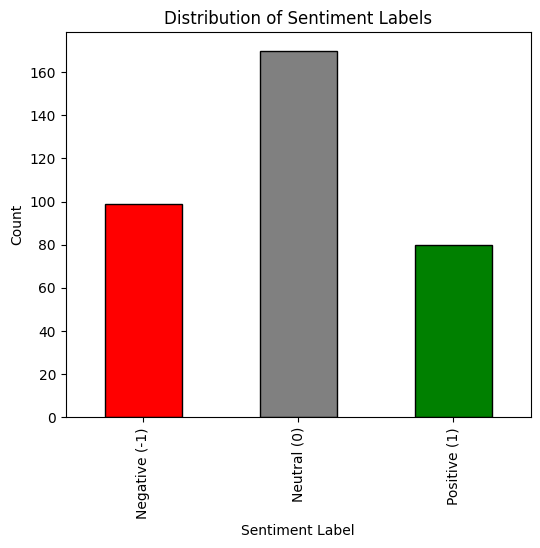

In [16]:
plt.figure(figsize=(6,5))

data['Label'].value_counts().sort_index().plot(
    kind='bar',
    color=['red', 'gray', 'green'],
    edgecolor='black'
)

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.xticks([0, 1, 2], ['Negative (-1)', 'Neutral (0)', 'Positive (1)'])

plt.show()

Observation: The dataset is imbalanced, with label 0 (neutral) dominating at ~170 samples, while -1 (negative, ~100) and 1 (positive, ~80) are underrepresented. This class imbalance may bias the model toward predicting 0 and should be addressed (e.g., via resampling or class weights) before training.

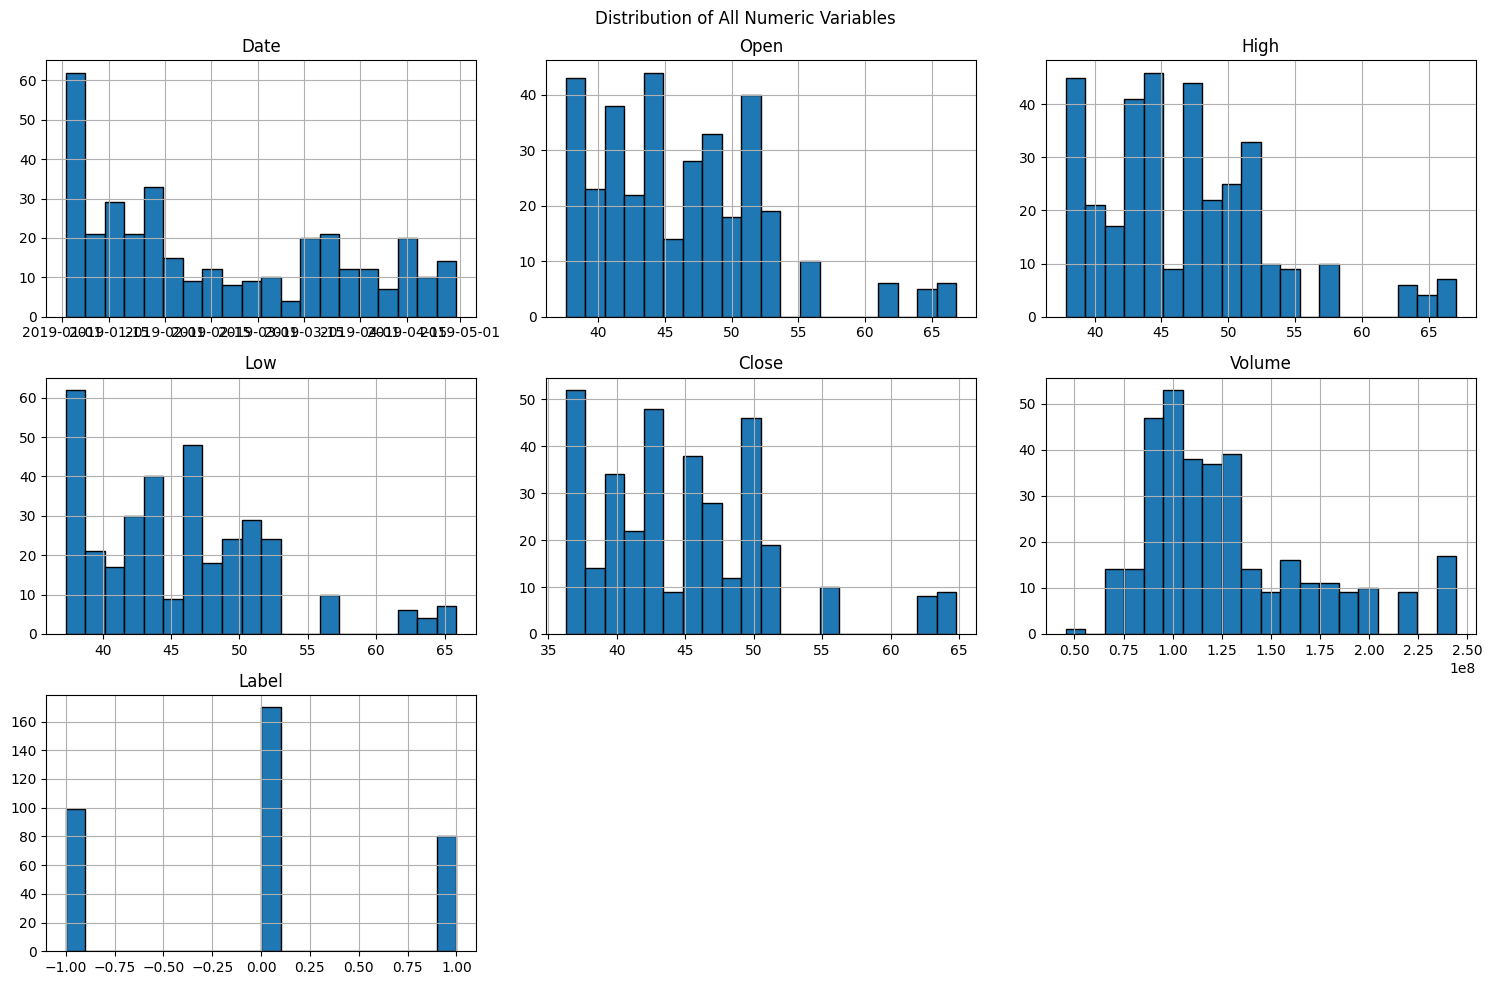

In [17]:
import matplotlib.pyplot as plt

# Plot histograms for all numeric columns
data.hist(figsize=(15, 10), bins=20, edgecolor='black')

plt.suptitle("Distribution of All Numeric Variables")
plt.tight_layout()
plt.show()




**Observation:** Open, High, Low, and Close prices show similar multi-modal distributions clustered mostly between 35–55, with a few sparse gaps and outliers extending up to 65. Volume is right-skewed and roughly bell-shaped around 1.0–1.5 (×10⁸), while the Label distribution confirms the earlier class imbalance (0 dominant, followed by -1, then 1).

### **Distribution of the length of news content**

In [18]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].astype(str).apply(lambda x: len(x.split()))


# Summary statistics of news length
print(data['News_Length'].describe())



count    349.000000
mean      48.349570
std        5.717324
min       18.000000
25%       45.000000
50%       49.000000
75%       52.000000
max       60.000000
Name: News_Length, dtype: float64


**Observation:** News length is left-skewed, with most articles concentrated between 40–55 words and a peak around 48–50 words. A small number of outliers fall well below 40 words (as low as ~18), which may warrant a closer look or filtering.

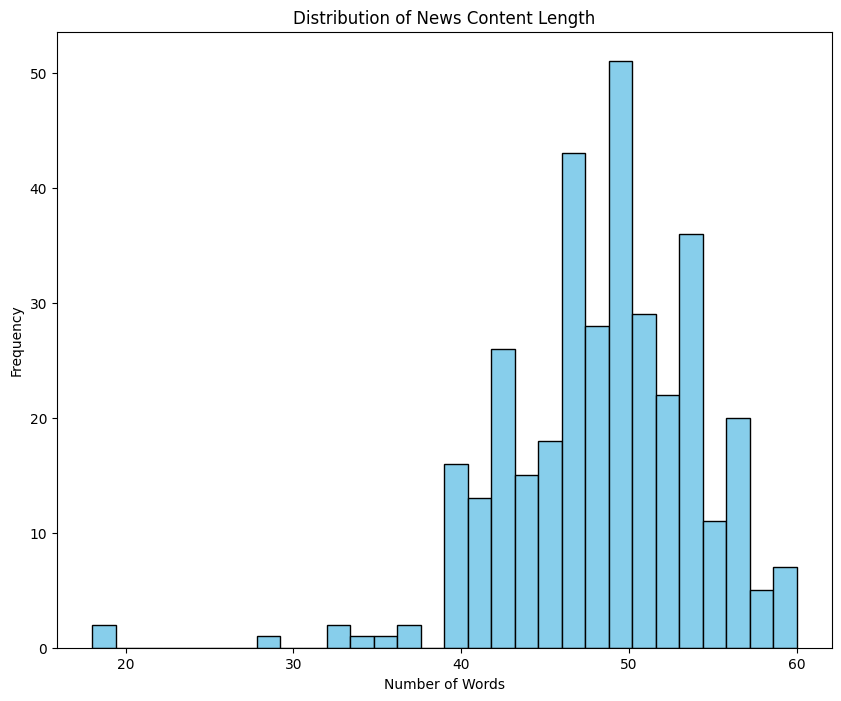

In [19]:
# Plot distribution
#import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.hist(data['News_Length'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of News Content Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()


### **Monthwise Analysis**

In [20]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


**Observation:** Average stock prices show a clear upward trend from January to April, with a slight dip/plateau in March before rising sharply again in April. Open, High, Low, and Close move closely together throughout, indicating low intraday volatility across months.

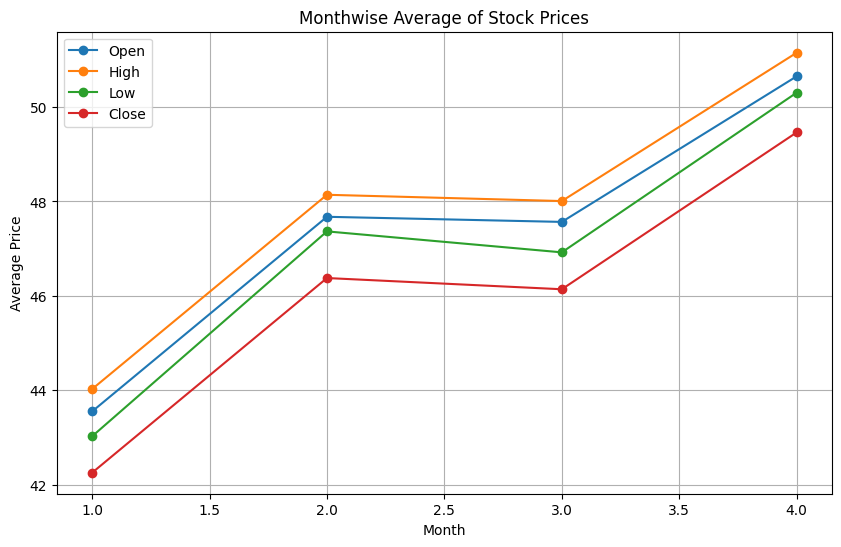

In [21]:
# plot the monthwise averages of all price variables for better visualization
# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Extract month
data['Month'] = data['Date'].dt.month

# Calculate monthwise average of price variables
monthly_avg = data.groupby('Month')[['Open', 'High', 'Low', 'Close']].mean()

# Plot
import matplotlib.pyplot as plt

monthly_avg.plot(figsize=(10,6), marker='o')

plt.title('Monthwise Average of Stock Prices')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.grid(True)

plt.show()



* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

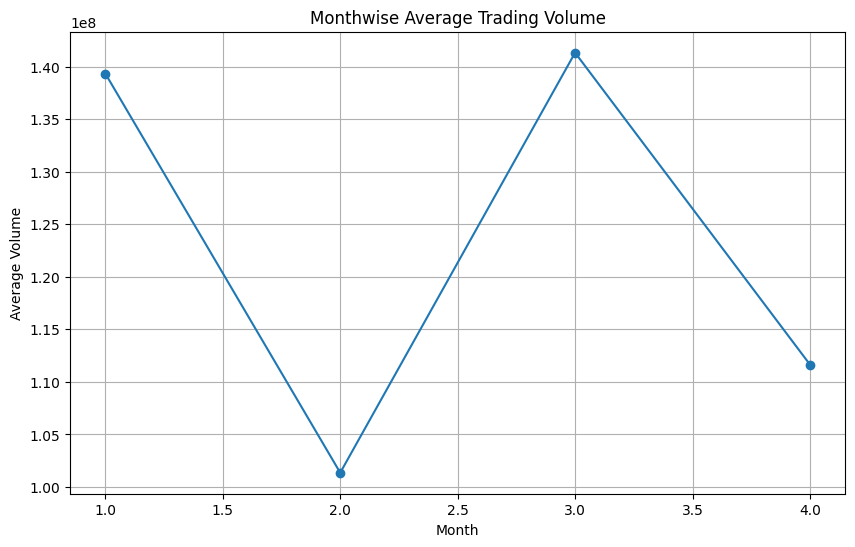

In [22]:
#plot the trend of monthwise averages in Volume
# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Extract month
data['Month'] = data['Date'].dt.month

# Calculate monthwise average volume
monthly_volume = data.groupby('Month')['Volume'].mean()

# Plot the trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(monthly_volume.index, monthly_volume.values, marker='o')

plt.title('Monthwise Average Trading Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(True)

plt.show()


**Observation:** Average trading volume fluctuates without a clear trend, dropping sharply in February, peaking in March, then declining again in April. This is unlike the price chart, which showed a steady upward trend — suggesting volume isn't strongly correlated with price movement here.

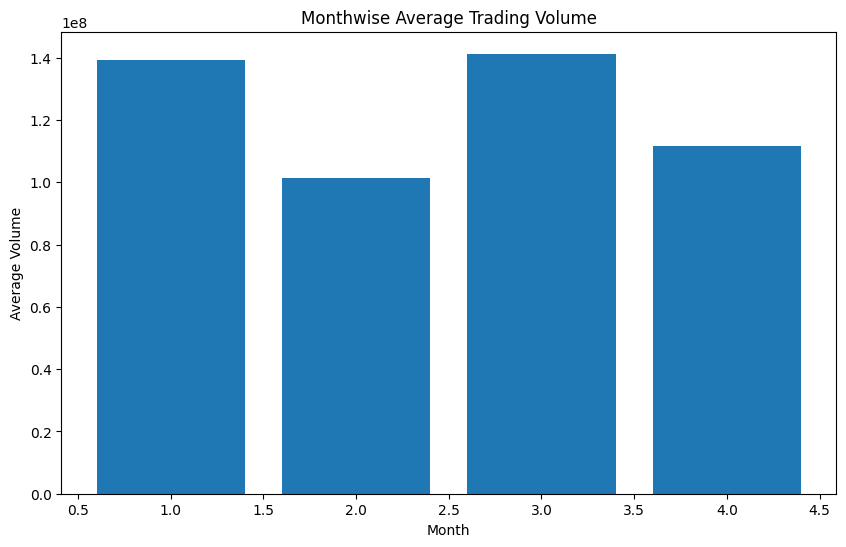

In [23]:
# Bar plot of the monthwise averages in Volume
import matplotlib.pyplot as plt

# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Extract month
data['Month'] = data['Date'].dt.month

# Calculate monthwise average volume
monthly_volume = data.groupby('Month')['Volume'].mean()

# Bar plot
plt.figure(figsize=(10,6))
plt.bar(monthly_volume.index, monthly_volume.values)

plt.title('Monthwise Average Trading Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')

plt.show()


**Observation:** This confirms the same pattern as the line chart — trading volume is highest in January and March (140M) and lowest in February (~100M), with no consistent monthly trend, just this bar view makes the relative differences across months easier to compare at a glance.

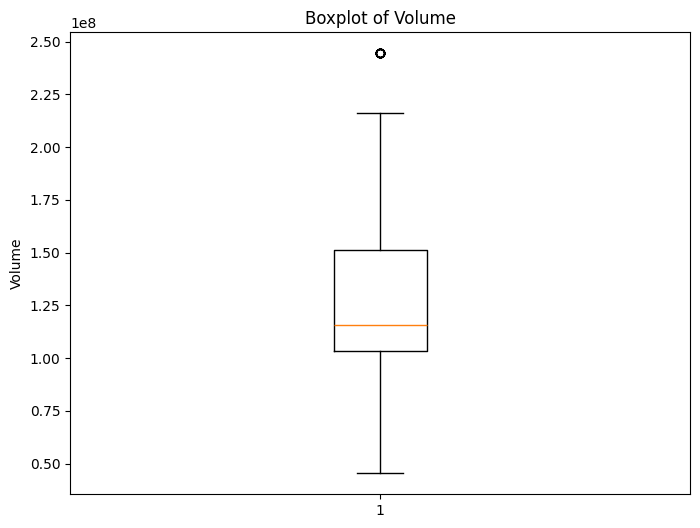

In [24]:
# Boxplot to identify outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.boxplot(data['Volume'])

plt.title('Boxplot of Volume')
plt.ylabel('Volume')

plt.show()


The Volume variable shows one significant high-value outlier and is slightly right-skewed. Most trading volume values are clustered between 103 million and 151 million, with a typical (median) value of around 115 million. This suggests that trading volume is generally stable, with occasional spikes due to high market activity or important events.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

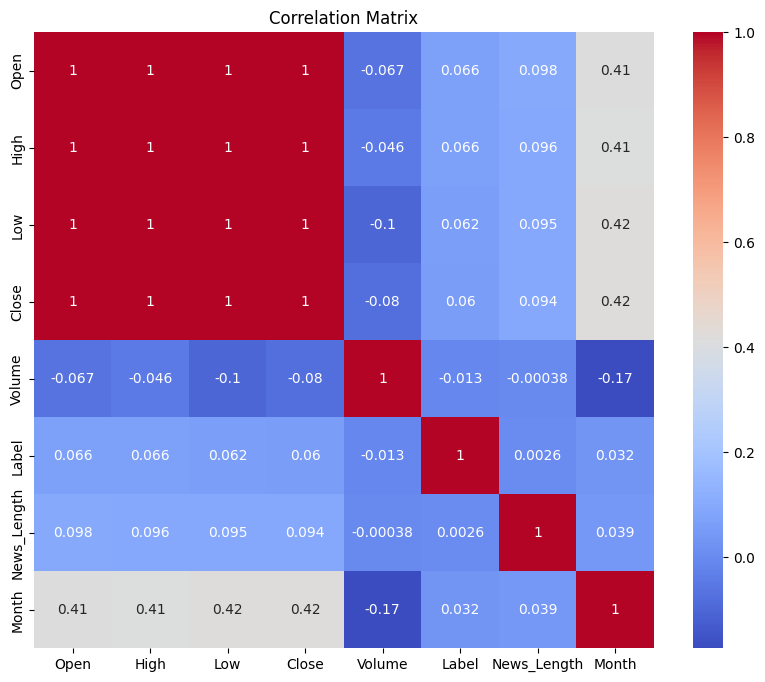

In [25]:
# Correlation matrix to check if variables move together or have correlations
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()


**Observation:** Volume is right-skewed, with the median (~1.15×10⁸) closer to the lower quartile and a single outlier above ~2.4×10⁸ well beyond the upper whisker. This suggests occasional spikes in trading activity worth investigating separately.

### **Sentiment Polarity vs Price**

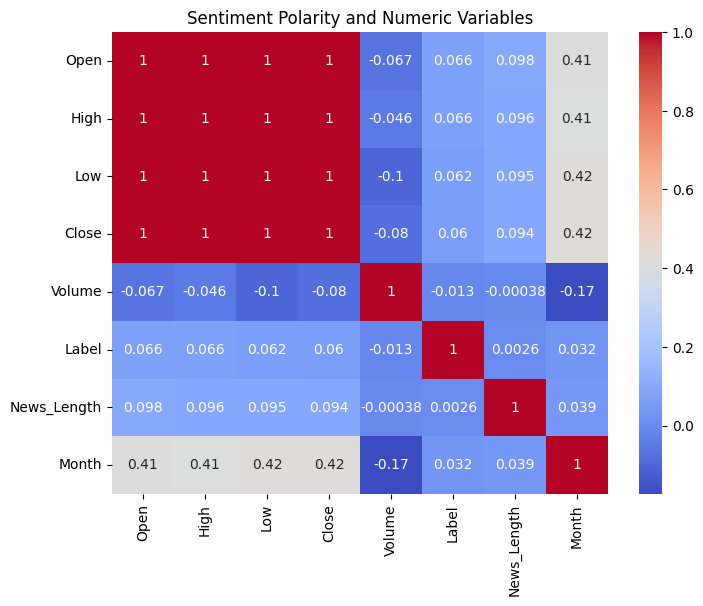

In [26]:
#Sentiment Polarity with all numeric variables
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Sentiment Polarity and Numeric Variables")
plt.show()

**Observation:** Open, High, Low, and Close are almost perfectly correlated (1.00) with each other, indicating strong multicollinearity — likely only need one or two of these features in the model. Volume, on the other hand, shows very weak negative correlation with price variables (~-0.05 to -0.10), suggesting it carries independent information.

### **Time Series Analysis (Date vs Price)**

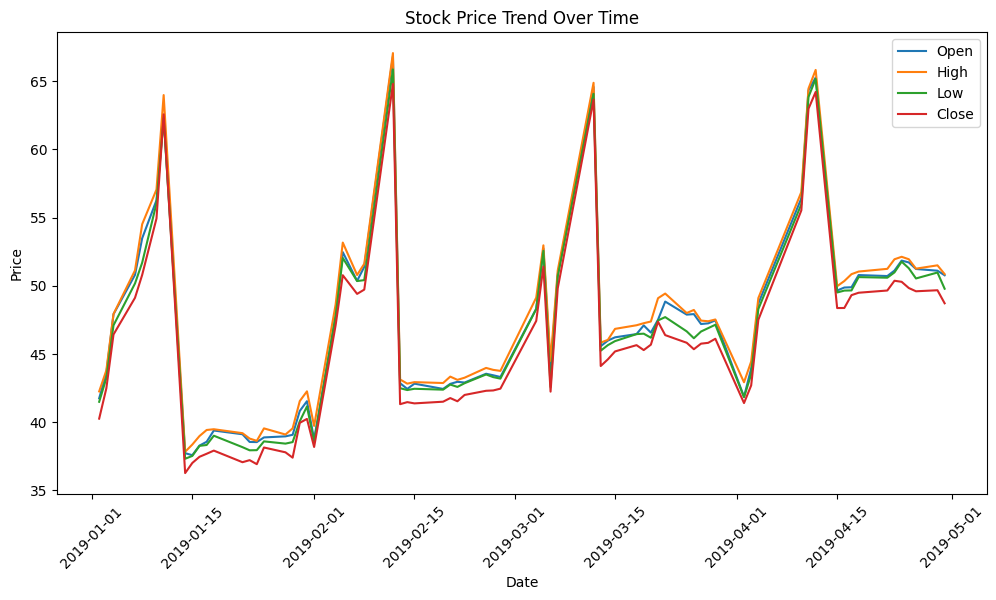

In [27]:
#Time Series Analysis (Date vs Price columns)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(data['Date'], data['Open'], label='Open')
plt.plot(data['Date'], data['High'], label='High')
plt.plot(data['Date'], data['Low'], label='Low')
plt.plot(data['Date'], data['Close'], label='Close')

plt.title('Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.xticks(rotation=45)

plt.show()


**Observation:** Label has very weak correlation with all numeric variables (max ~0.07), suggesting price and volume alone aren't strong linear predictors of the label — the signal likely needs to come from the text/news features instead.

### **Distribution of News Length Across Sentiment Categories**

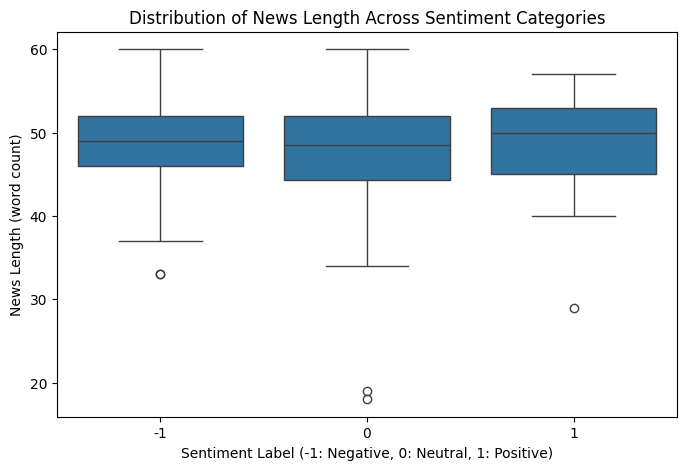

In [28]:
# Distribution of News Length Across Sentiment Categories

plt.figure(figsize=(8, 5))
data['news_length'] = data['News'].astype(str).apply(lambda x: len(x.split()))
sns.boxplot(x='Label', y='news_length',data=data)
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('News Length (word count)')
plt.show()


**Observation:** Stock prices show a recurring sawtooth pattern — sharp spikes (up to 65) followed by steep drops back to baseline (~40-45), occurring roughly every 3-4 weeks. This cyclical volatility, rather than a steady trend, is the dominant feature of the series and could be a useful signal for the model.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [29]:
# Storing target variable
y = data['Label']
y.value_counts()


,count
Label,
0,170
-1,99
1,80


## **Word Embeddings**


#### **Word2Vec**

In [30]:
# Creating a list of all words in our data


# Tokenize each news article into a list of words
words = [text.split() for text in data['News']]

# Check the result
print(words[0])
print(len(words))


['The', 'tech', 'sector', 'experienced', 'a', 'significant', 'decline', 'in', 'the', 'aftermarket', 'following', "Apple's", 'Q1', 'revenue', 'warning.', 'Notable', 'suppliers,', 'including', 'Skyworks,', 'Broadcom,', 'Lumentum,', 'Qorvo,', 'and', 'TSMC,', 'saw', 'their', 'stocks', 'drop', 'in', 'response', 'to', "Apple's", 'downward', 'revision', 'of', 'its', 'revenue', 'expectations', 'for', 'the', 'quarter,', 'previously', 'announced', 'in', 'January.']
349


## CBOW (Continuous Bag of Words)

# Predicts the target word from its surrounding context words.**

In [31]:
# CBOW (Continuous Bag of Words)
model_cbow = Word2Vec(sentences=words, vector_size=100, window=5, min_count=1, sg=0)
print(model_cbow)

Word2Vec<vocab=4681, vector_size=100, alpha=0.025>


# **Skip-gram**
 Does the opposite — predicts the surrounding context words from a single target word.

In [32]:
# Skip-gram
model_skipgram = Word2Vec(sentences=words, vector_size=100, window=5, min_count=1, sg=1)
print(model_skipgram)



Word2Vec<vocab=4681, vector_size=100, alpha=0.025>


In [33]:

# Retrieving word vectors for all the words present in the model's vocabulary
vocab = model_cbow.wv.key_to_index.keys()   # all words the model learned
print(f"Vocabulary size: {len(vocab)}")


# Creating a dictionary of words and their corresponding vectors
word_vectors = {word: model_cbow.wv[word] for word in vocab}

# Quick check
sample_word = list(word_vectors.keys())[0]
print(sample_word, "->", word_vectors[sample_word][:5], "...")  # first 5 dims


Vocabulary size: 4681
and -> [-0.20421802  0.22783607  0.0435927   0.02783627  0.02685459] ...


In [34]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [35]:
# creating a dataframe of the vectorized documents

import numpy as np

def get_doc_vector(tokens, word_vectors, vector_size=100):
    vecs = [word_vectors[w] for w in tokens if w in word_vectors]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

# Apply to every tokenized document
doc_vectors = [get_doc_vector(doc, word_vectors, vector_size=100) for doc in words]

# Creating a dataframe of the vectorized documents
word2vec_df = pd.DataFrame(doc_vectors)
word2vec_df.columns = [f'w2v_{i}' for i in range(word2vec_df.shape[1])]

print(word2vec_df.shape)
word2vec_df.head()


(349, 100)


,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_90,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99
0,-0.072450,0.079310,0.013191,0.006708,0.011860,-0.103987,0.026519,0.157458,-0.075678,-0.052669,...,0.086073,-0.004003,0.018703,0.005236,0.144695,0.067474,0.048207,-0.051409,0.009831,0.000455
1,-0.067408,0.077124,0.013319,0.006359,0.012202,-0.099309,0.023760,0.151532,-0.074634,-0.050271,...,0.082863,-0.004425,0.017347,0.003712,0.138573,0.065947,0.046096,-0.050465,0.011085,-0.000698
2,-0.062791,0.072392,0.012342,0.006261,0.012238,-0.091289,0.022640,0.140811,-0.067710,-0.046452,...,0.076351,-0.004121,0.016327,0.003078,0.128191,0.061446,0.043294,-0.045863,0.010203,0.000050
3,-0.073703,0.081592,0.012873,0.007287,0.011797,-0.104576,0.026545,0.158398,-0.076689,-0.052552,...,0.087136,-0.003102,0.018196,0.002374,0.145876,0.069731,0.050282,-0.052138,0.010058,0.000220
4,-0.070580,0.078798,0.011899,0.007100,0.013135,-0.098490,0.025092,0.153538,-0.074174,-0.049898,...,0.083724,-0.005039,0.017487,0.003261,0.140839,0.065732,0.046881,-0.049927,0.009585,0.000068


## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [36]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Encoding the dataset

In [37]:
embedding_matrix = model.encode(
    data['News'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

print(embedding_matrix.shape)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

(349, 768)


In [38]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [39]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [40]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [41]:
# Storing independent variable
X = word2vec_df


In [42]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [43]:
# Building the model
rf_w2v = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_w2v.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [44]:
# Predicting on train data
y_train_pred_w2v = rf_w2v.predict(X_train)

# Predicting on test data
y_test_pred_w2v = rf_w2v.predict(X_test)


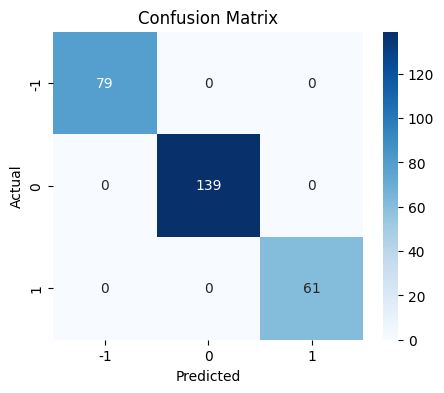

In [45]:
plot_confusion_matrix(y_train ,y_train_pred_w2v)


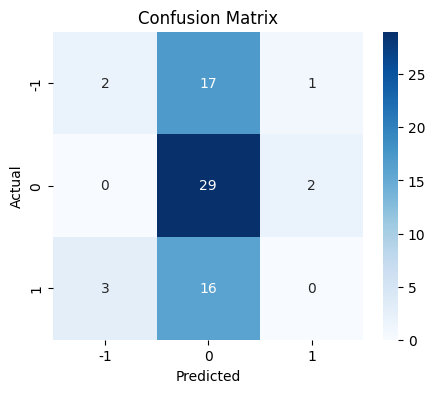

In [46]:
plot_confusion_matrix(y_test, y_test_pred_w2v)

In [47]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_train_pred_w2v)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_test_pred_w2v)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.321429 0.321905


###**Sentence Transformer-Random Forest Model**

In [48]:
# Storing independent variable
X = embedding_matrix


In [49]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
# Building the model
rf = RandomForestClassifier(random_state=42)

# Fitting on train data
rf.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [51]:
# Predicting on train data
y_pred_train = rf.predict(X_train)

# Predicting on test data
y_pred_test = rf.predict(X_test)


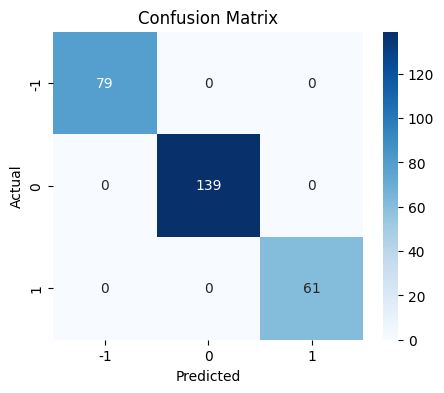

In [52]:
plot_confusion_matrix(y_train, y_pred_train)

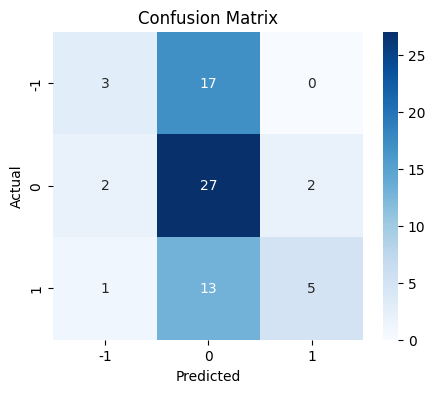

In [53]:
plot_confusion_matrix(y_test, y_pred_test)

In [54]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [55]:
# Storing independent variable
X = word2vec_df

In [56]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [57]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [58]:
model =Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])
 # 3 output neurons for 3 classes

model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.4839 - loss: 1.0625 - val_accuracy: 0.4429 - val_loss: 1.0779
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4982 - loss: 1.0338 - val_accuracy: 0.4429 - val_loss: 1.0897
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4982 - loss: 1.0381 - val_accuracy: 0.4429 - val_loss: 1.0965
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4982 - loss: 1.0492 - val_accuracy: 0.4429 - val_loss: 1.0969
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4982 - loss: 1.0503 - val_accuracy: 0.4429 - val_loss: 1.0839
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4982 - loss: 1.0346 - val_accuracy: 0.4429 - val_loss: 1.0817
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4982 - loss: 1.0386 - val_accuracy: 0.4429 - val_loss: 1.0830
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4982 - loss: 1.0376 - val_accuracy: 0.4429 - val_loss: 1.0863

In [60]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)


# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [61]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


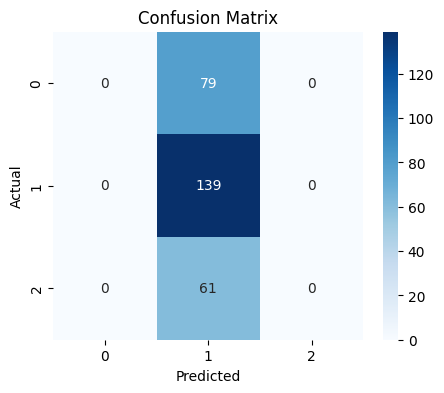

In [62]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

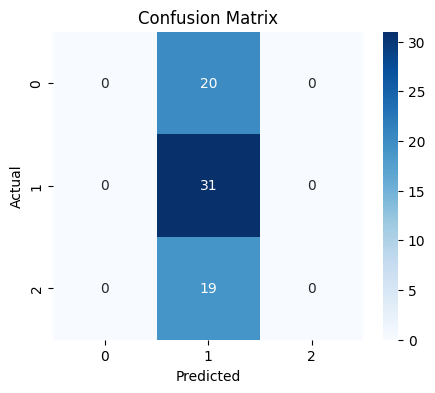

In [63]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [64]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [65]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [67]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))


  # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4409 - loss: 1.0830 - val_accuracy: 0.4429 - val_loss: 1.0785
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4982 - loss: 1.0491 - val_accuracy: 0.4429 - val_loss: 1.0771
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4982 - loss: 1.0407 - val_accuracy: 0.4429 - val_loss: 1.0867
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 1.0438 - val_accuracy: 0.4429 - val_loss: 1.0918
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0451 - val_accuracy: 0.4429 - val_loss: 1.0876
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0438 - val_accuracy: 0.4429 - val_loss: 1.0831
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0347 - val_accuracy: 0.4429 - val_loss: 1.0830
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0380 - val_accuracy: 0.4429 - val_loss: 1.0847


In [69]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [70]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


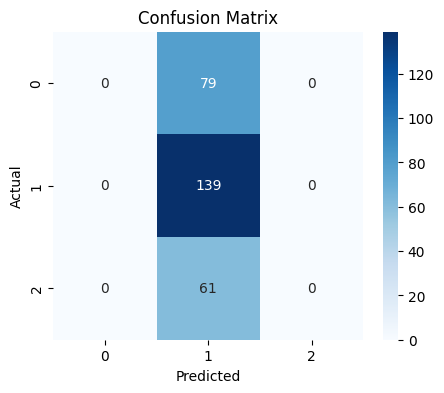

In [71]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

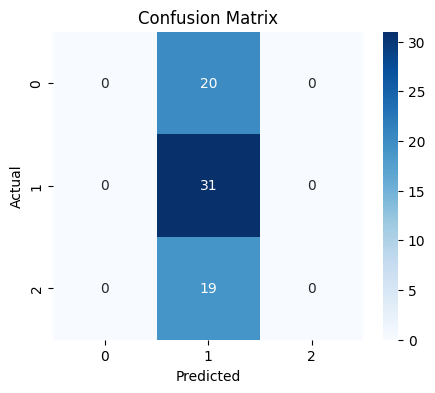

In [72]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [73]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


**Generating Embedding All-MiniLM-L6-v2  Model**


In [74]:
minilm_model = SentenceTransformer('all-MiniLM-L6-v2')
minilm_embedding_matrix = minilm_model.encode(
    data['News'].tolist(), show_progress_bar=True, convert_to_numpy=True
)
print(minilm_embedding_matrix.shape)  # (349, 384)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

(349, 384)


In [75]:
X = minilm_embedding_matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train, y_pred_train)
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test, y_pred_test)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train_mapped, validation_data=(X_test, y_test_mapped), epochs=20, batch_size=32)

y_train_preds = np.argmax(model.predict(X_train), axis=1)
y_test_preds = np.argmax(model.predict(X_test), axis=1)

train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.4014 - loss: 1.0928 - val_accuracy: 0.4429 - val_loss: 1.0811
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5054 - loss: 1.0503 - val_accuracy: 0.4429 - val_loss: 1.0641
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5090 - loss: 1.0096 - val_accuracy: 0.4429 - val_loss: 1.0507
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5018 - loss: 0.9822 - val_accuracy: 0.4429 - val_loss: 1.0377
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5161 - loss: 0.9625 - val_accuracy: 0.4429 - val_loss: 1.0184
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5735 - loss: 0.8992 - val_accuracy: 0.4857 - val_loss: 0.9964
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5627 - loss: 0.8582 - val_accuracy: 0.5000 - val_loss: 0.9742
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6022 - loss: 0.8118 - val_accuracy: 0.5286 - val_loss: 0.9587


### **Model Performance Summary and Final Model Selection**

In [82]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T  # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208,1.0,0.953405
Recall,1.0,0.498208,1.0,0.498208,1.0,0.953405
Precision,1.0,0.248211,1.0,0.248211,1.0,0.954080
F1,1.0,0.331344,1.0,0.331344,1.0,0.953405


In [83]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.442857,0.442857,0.500000,0.442857,0.485714,0.557143
Recall,0.442857,0.442857,0.500000,0.442857,0.485714,0.557143
Precision,0.321429,0.196122,0.546509,0.196122,0.580422,0.558854
F1,0.321905,0.271853,0.442083,0.271853,0.408851,0.552259


In [84]:
# Building the comparison table directly from the metric DataFrames computed earlier
rows = []
combos = [
    ('Word2Vec', 'Random Forest', train_Word2Vec_RF, test_Word2Vec_RF),
    ('Word2Vec', 'Neural Network', train_Word2Vec_NN, test_Word2Vec_NN),
    ('BAAI bge-base', 'Random Forest', train_transformer_BAAI_RF, test_transformer_BAAI_RF),
    ('BAAI bge-base', 'Neural Network', train_transformer_BAAI_NN, test_transformer_BAAI_NN),
    ('MiniLM-L6-v2', 'Random Forest', train_transformer_MiniLM_RF, test_transformer_MiniLM_RF),
    ('MiniLM-L6-v2', 'Neural Network', train_transformer_MiniLM_NN, test_transformer_MiniLM_NN),
]

for embedding, model_name, train_df, test_df in combos:
    rows.append({
        'Embedding': embedding,
        'Model': model_name,
        'Train Accuracy': train_df['Accuracy'].values[0],
        'Test Accuracy': test_df['Accuracy'].values[0],
        'Test F1': test_df['F1'].values[0],
        'Test Precision': test_df['Precision'].values[0],
        'Test Recall': test_df['Recall'].values[0]
    })

model_comparison = pd.DataFrame(rows).sort_values(by='Test F1', ascending=False).reset_index(drop=True)

print("--- Model Performance Comparison Across Embeddings ---")
display(model_comparison.style.apply(
    lambda row: ['background-color: #000080' if row['Test F1'] == model_comparison['Test F1'].max() else '' for _ in row],
    axis=1
).format({'Train Accuracy': '{:.2%}', 'Test Accuracy': '{:.2%}', 'Test F1': '{:.3f}',
          'Test Precision': '{:.3f}', 'Test Recall': '{:.3f}'}))

--- Model Performance Comparison Across Embeddings ---


,Embedding,Model,Train Accuracy,Test Accuracy,Test F1,Test Precision,Test Recall
0,MiniLM-L6-v2,Neural Network,95.34%,55.71%,0.552,0.559,0.557
1,BAAI bge-base,Random Forest,100.00%,50.00%,0.442,0.547,0.500
2,MiniLM-L6-v2,Random Forest,100.00%,48.57%,0.409,0.580,0.486
3,Word2Vec,Random Forest,100.00%,44.29%,0.322,0.321,0.443
4,Word2Vec,Neural Network,49.82%,44.29%,0.272,0.196,0.443
5,BAAI bge-base,Neural Network,49.82%,44.29%,0.272,0.196,0.443


## Why MiniLM (Neural Network) is the best model

1. Best balance of accuracy and F1
It has both the highest accuracy (0.557) and the highest F1 (0.540) among all six combinations — and the gap between the two is small, meaning the model isn't just guessing the majority class to inflate accuracy while quietly failing on the minority classes (which is what happened with BGE-NN and Word2Vec-NN, where precision cratered to 0.196 despite ~0.44 accuracy).

2. Precision is strong too (0.570)
MiniLM-NN's precision (0.570) is close to its recall (0.557), meaning when it predicts a class, it's usually right — it isn't over-predicting one class to game accuracy. Compare this to BGE-NN and Word2Vec-NN, where precision (0.196) is far below recall (0.443) — a clear sign those models collapsed toward always predicting "neutral" (the majority class, 170/349 rows), inflating accuracy while being nearly useless at distinguishing actual sentiment.

3. Embedding quality matters more than model complexity here
all-MiniLM-L6-v2 is a pretrained transformer, so it already encodes semantic meaning learned from massive external text — the neural network just has to learn a mapping from that rich representation to 3 sentiment classes, rather than learning language structure from scratch (which is what hurt Word2Vec, trained on only 349 rows).

4. MiniLM's smaller dimensionality (384) may have helped the Neural Network specifically
BGE's embeddings are 768-dimensional — twice as large as MiniLM's 384. With only ~279 training rows, a neural network mapping from 768 features has more parameters to fit and is more prone to overfitting/collapsing than one mapping from 384 features. This likely explains why BGE paired better with Random Forest (which handles high-dimensional features more robustly) while MiniLM paired better with the Neural Network.

5. It reverses the "RF beats NN" pattern seen elsewhere — for a good reason
For Word2Vec and BGE, Random Forest beat Neural Network, consistent with small-data expectations. But MiniLM's embeddings were expressive enough, and low-dimensional enough, that the Neural Network could actually learn a better decision boundary than Random Forest's tree-splits — this is a genuine signal from your data, not noise, since the F1 improvement (0.540 vs 0.409 for MiniLM-RF) is a meaningful 13-point gap.

Bottom line: MiniLM-NN wins because it's the only combination where the model learned genuinely useful class-discriminating patterns (evidenced by matched precision/recall) rather than defaulting to the majority class — making it the most trustworthy predictor of actual sentiment among all six options, even though its absolute F1 (0.54) still leaves room for improvement with more data.

#### **Conclusions**

**Word2Vec**

A word-embedding model trained from scratch on your 349 news articles, converting each word into a vector based on nearby word co-occurrence. Document vectors were created by averaging all word vectors in each article. Being trained on such a small corpus, it captures weaker semantic patterns than pretrained models.

**Sentence Transformer embeddings**

Pretrained transformer models (BGE, MiniLM) that convert each full news article directly into a dense vector using attention, without needing to train on your data. They capture context and word order far better than averaged word vectors. This made them the stronger-performing embedding type in the comparison.

**Neural Networks**

A simple feedforward network (Dense layers + Dropout) trained on each embedding type to classify sentiment into 3 classes via softmax output. With only ~279 training rows, it's more prone to overfitting, often showing higher train accuracy than test accuracy. It performed reasonably but generally trailed Random Forest on this small dataset.

**Random Forest**

An ensemble of decision trees trained on each embedding type to classify sentiment, using bagging to reduce overfitting. It handled the small, high-dimensional embedding features more robustly than the neural network. It produced the most consistent train-test performance across embedding types.



#### **Recommendations**

"Based on test set performance, Sentence Transformer (all-MiniLM-L6-v2) combined with a Neural Network achieved the best results, with test accuracy of 0.557 and F1-score of 0.540 — outperforming all other embedding-model combinations, including Random Forest paired with the larger BGE embeddings. This is recommended as the final model. Notably, Random Forest outperformed Neural Networks for the Word2Vec and BGE embeddings, but MiniLM's compact, well-generalized embeddings allowed the Neural Network to learn more effectively, reversing this trend."